In [2]:
import numpy as np
from scipy import signal
from scipy.io import wavfile
from scipy.fft import fftshift
import matplotlib.pyplot as plt
import librosa
from scipy.signal import hilbert, butter, lfilter
import os

In [3]:
def plot_spectogram(signal, srate,file):
    stft = librosa.stft(signal)
    spect = np.abs(stft)
    spectogram_db = librosa.amplitude_to_db(spect)
    plt.Figure(figsize=(10,4))
    img = librosa.display.specshow(spectogram_db,y_axis='hz', x_axis='time', sr=srate, cmap='inferno', fmin=4096)
    plt.colorbar(img, format="%+2.0f dB")
    plt.savefig(file+".png")
    plt.close()

In [4]:
folder_plots = 'YellowHammer/plots/'

dirs_walk = [x[0] for x in os.walk(folder_plots) ]
dirs_walk = dirs_walk[1:]

for direct in dirs_walk:
    files = os.listdir(direct)

    song_file = files[0][:-4]
    samplerate, data = wavfile.read("YellowHammer/Training_set_YH_songs/ALL_Songs_CUT/"+song_file)
    data = data.astype(float)

    plot_spectogram(data, samplerate, direct)

In [5]:
def plot_filter(b,a):
    w, h = signal.freqs(b, a)
    plt.semilogx(w, 20 * np.log10(abs(h)))
    plt.title('Butterworth filter frequency response')
    plt.xlabel('Frequency [radians / second]')
    plt.ylabel('Amplitude [dB]')
    plt.margins(0, 0.1)
    plt.grid(which='both', axis='both')
    plt.axvline(100, color='green') # cutoff frequency
    plt.show()

In [6]:
# I got the code from here https://stackoverflow.com/questions/12093594/how-to-implement-band-pass-butterworth-filter-with-scipy-signal-butter
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band') # from scipy.signal
    return b, a


def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    #plot_filter(b,a)
    y = lfilter(b, a, data)
    return y

In [7]:
# I got this code from here https://github.com/musikalkemist/AudioSignalProcessingForML/blob/master/8-%20Implementing%20the%20amplitude%20envelope/Implementing%20the%20amplitude%20envelope.ipynb
def fancy_amplitude_envelope(signal, frame_size=512, hop_length=1):
    # from 
    """Fancier Python code to calculate the amplitude envelope of a signal with a given frame size."""
    return np.array([max(signal[i:i+frame_size]) for i in range(0, len(signal), hop_length)])

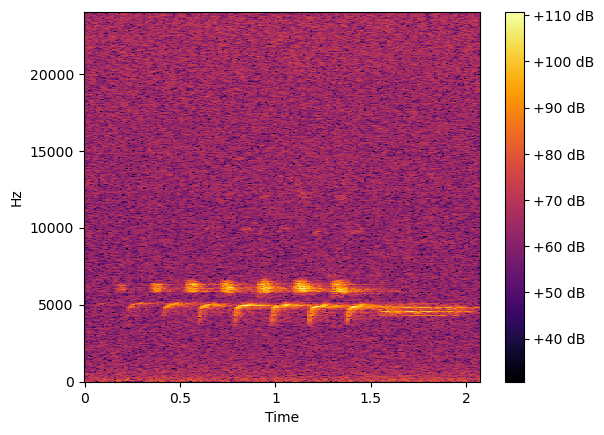

14487.297195509285 1658.0
14180.161696071345 1658.0
20953.74127765899 1658.0
16740.9713283004 1658.0
16312.571731230393 1658.0
16352.587523319893 1658.0
17130.876548115062 1658.0
12194.529438079502 1658.0
9251.130903171925 1658.0
9647.247885358527 1658.0
10601.95814228122 1658.0
9861.612561759419 1658.0
8573.466921316503 1658.0
7621.917712355537 1658.0
9219.353167778387 1658.0
9164.855760866145 1658.0
7952.291563061106 1658.0
7404.941386749766 1658.0
8153.970333229791 1658.0
8169.02161733606 1658.0
6987.615713176303 1658.0
7381.685723088125 1658.0
6362.712783482263 1658.0
6139.528342782085 1658.0
7628.866914847692 1658.0
7196.53335105597 1658.0
6417.823815899531 1658.0
7229.017873080196 1658.0
7644.5968832024455 1658.0
5686.037576969447 1658.0
5593.829633159905 1658.0
5441.956985705947 1658.0
5297.0276027396 1658.0
5824.213913879454 1658.0
5384.2645499850305 1658.0
6037.486073230246 1658.0
4955.539564911537 1658.0
5659.24978578822 1658.0
5310.910553559891 1658.0
4978.653041019388 1658.

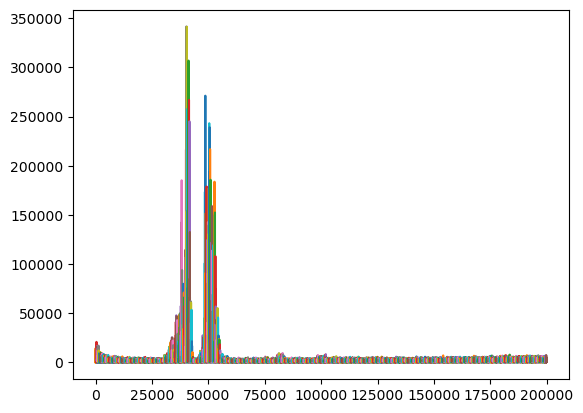

In [9]:
song_file = "YellowHammer/Training_set_YH_songs/ALL_Songs_CUT/20240726_forest_50m_0_6_test1_YH_5_D_2.wav"
samplerate, data = wavfile.read(song_file)
data = data.astype(float)

n_ff= 2048

stft = librosa.stft(data, n_fft=n_ff)
spect = np.abs(stft)
spectogram_db = librosa.amplitude_to_db(spect)
plt.Figure(figsize=(10,4))
img = librosa.display.specshow(spectogram_db,y_axis='hz', x_axis='time', n_fft=n_ff,sr=samplerate, cmap='inferno')
plt.colorbar(img, format="%+2.0f dB")
plt.show()

#plt.plot(data)
plt.plot(librosa.amplitude_to_db(np.abs(data)))

k=0
for i in range(spect.shape[0]):
    kk = np.max(spect[i]) - np.max(np.abs(data))
    if kk>0:
        print(np.max(spect[i]) , np.max(np.abs(data)))
    plt.plot(list(range(k,k+spect[i].shape[0])),spect[i])
    k=k+spect[i].shape[0]

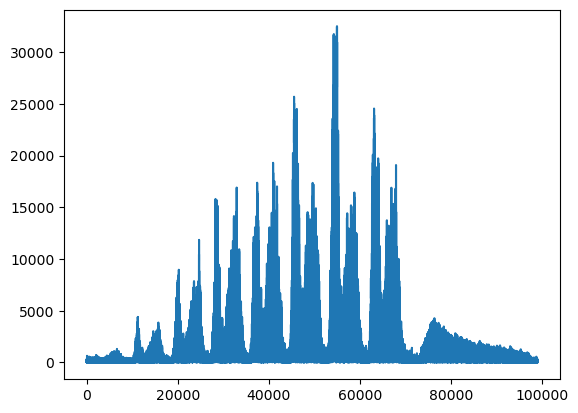

In [77]:
plt.plot(np.abs(data))

In [10]:
y = butter_bandpass_filter(data, 4000, 5000, samplerate, order=6)
z = butter_bandpass_filter(data, 6000, 8000, samplerate, order=6)

In [12]:
plot_spectogram(y, samplerate,'')

Text(0.5, 1.0, 'Amplitude Envelope')

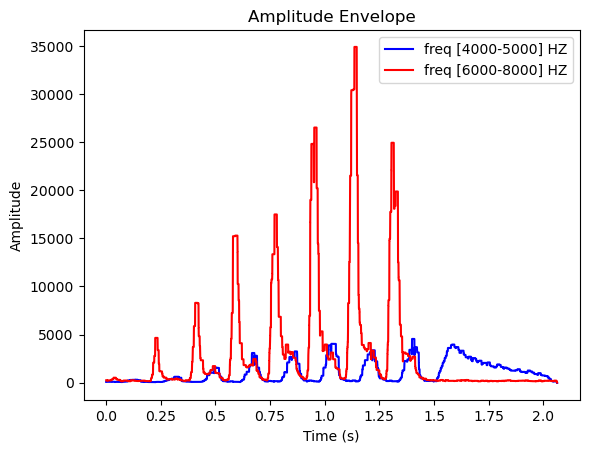

In [ ]:
FRAME_SIZE = 512
HOP_LENGTH = 1

#plt.plot(y)
amplitude_envelope = fancy_amplitude_envelope(y,FRAME_SIZE, HOP_LENGTH)
amplitude_envelope_2 = fancy_amplitude_envelope(z,FRAME_SIZE, HOP_LENGTH)

plt.plot(amplitude_envelope, color="blue", label="freq [4000-5000] HZ")
plt.plot(amplitude_envelope_2, color="red", label="freq [6000-8000] HZ")

xticks = np.arange(0, 2.25, 0.25)
plt.xticks(xticks*samplerate,labels=xticks)
plt.legend()
plt.ylabel("Amplitude")
plt.xlabel("Time (s)")
plt.title("Amplitude Envelope")

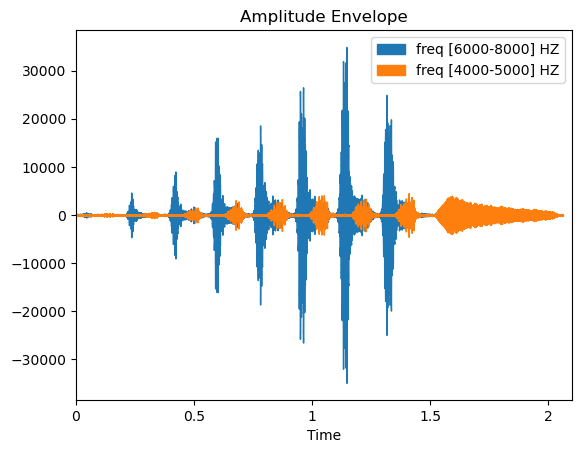

In [ ]:
FRAME_SIZE = 512
HOP_LENGTH = 1

#plt.plot(y)
amplitude_envelope = fancy_amplitude_envelope(y,FRAME_SIZE, HOP_LENGTH)
amplitude_envelope_2 = fancy_amplitude_envelope(z,FRAME_SIZE, HOP_LENGTH)


fig, ax = plt.subplots(nrows=1, sharex=True)
ax.set(xlim=[0, 2.1], title='Amplitude Envelope')
librosa.display.waveshow(z, sr=samplerate, ax=ax, marker='.', label='freq [6000-8000] HZ')
librosa.display.waveshow(y, sr=samplerate, ax=ax, marker='.', label='freq [4000-5000] HZ')
ax.legend()